# Tugas Pemrograman 1 Datmin
## Yusuf Fakhri Aldrian - 1906351096

### Asdos dan Kolaborator: Raniah Nur Hanami
### Topik: Best Books



Beberapa rujukan:

1.   https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
2.   https://chat.openai.com/chat, ChatGPT dengan beberapa prompt
3. https://matplotlib.org/stable/tutorials/colors/colormaps.html, untuk warna-warna dari Matplotlib
4. https://stackabuse.com/calculating-pearson-correlation-coefficient-in-python-with-numpy/
5. https://www.pythonfordatascience.org/anova-python/
6. https://colab.research.google.com/drive/1ClAIj-J0pkxnkv0fu4Ab50bclrqcjmel?authuser=1#scrollTo=uMqDvM0Q3IGl, notebook dari pembelajaran Pak Alfan
7. https://www.statsmodels.org/dev/examples/notebooks/generated/regression_plots.html 
8. https://www.statsmodels.org/dev/examples/notebooks/generated/robust_models_0.html
9. https://stackoverflow.com/questions/42261976/how-to-plot-statsmodels-linear-regression-ols-cleanly
10. https://stackoverflow.com/questions/23996118/replace-special-characters-in-a-string-in-python
11. https://stackoverflow.com/questions/42261976/how-to-plot-statsmodels-linear-regression-ols-cleanly
12. https://seaborn.pydata.org/generated/seaborn.jointplot.html
13. https://seaborn.pydata.org/generated/seaborn.heatmap.html

# Import Library

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import scipy.stats as scp
from scipy.stats import pearsonr

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

import scipy.stats as stats


import warnings
warnings.filterwarnings("ignore")

In [8]:
import statsmodels.api as sm
import statsmodels.formula as smf
from statsmodels.formula.api import ols
import re

In [9]:
!pip install -q gwpy

# Import Dataset

In [10]:
!gdown --id "1JWemKTC63VLH2kuuYLi3YHK0glMNvIHD"

/usr/local/lib/python3.8/dist-packages/gdown/cli.py:127: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1JWemKTC63VLH2kuuYLi3YHK0glMNvIHD
To: /content/books.csv
100% 72.0M/72.0M [00:00<00:00, 231MB/s]


In [11]:
df = pd.read_csv('/content/books.csv')
df = df.drop(columns=['Unnamed: 0'])
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.iloc[:100]

,bookId,title,series,author,rating,description,language,isbn,genres,characters,bookFormat,edition,pages,publisher,publishDate,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",Hardcover,First Edition,374,Scholastic Press,09/14/08,NaN,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",Paperback,US Edition,870,Scholastic Inc.,09/28/04,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",Paperback,NaN,324,Harper Perennial Modern Classics,05/23/06,07/11/60,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",Paperback,"Modern Library Classics, USA / CAN",279,Modern Library,10/10/00,01/28/13,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",Paperback,NaN,501,"Little, Brown and Company",09/06/06,10/05/05,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.10
5,19063.The_Book_Thief,The Book Thief,NaN,Markus Zusak (Goodreads Author),4.37,Librarian's note: An alternate cover edition c...,English,9780375831003,"['Historical Fiction', 'Fiction', 'Young Adult...","['Liesel Meminger', 'Hans Hubermann', 'Rudy St...",Hardcover,First American Edition,552,Alfred A. Knopf,03/14/06,09/01/05,['National Jewish Book Award for Children’s an...,1834276,"['1048230', '524674', '186297', '48864', '26211']",96.0,"['Molching (Germany)', 'Germany']",https://i.gr-assets.com/images/S/compressed.ph...,1372809,14168,3.80
6,170448.Animal_Farm,Animal Farm,NaN,"George Orwell, Russell Baker (Preface), C.M. W...",3.95,Librarian's note: There is an Alternate Cover ...,English,9780451526342,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...","['Snowball', 'Napoleon', 'Clover', 'Boxer', 'O...",Mass Market Paperback,NaN,141,Signet Classics,04/28/96,08/17/45,"['Prometheus Hall of Fame Award (2011)', 'Retr...",2740713,"

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52466 entries, 0 to 52465
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            52466 non-null  object 
 1   title             52466 non-null  object 
 2   series            23469 non-null  object 
 3   author            52466 non-null  object 
 4   rating            52466 non-null  float64
 5   description       51129 non-null  object 
 6   language          48662 non-null  object 
 7   isbn              52466 non-null  object 
 8   genres            52466 non-null  object 
 9   characters        52466 non-null  object 
 10  bookFormat        50994 non-null  object 
 11  edition           4955 non-null   object 
 12  pages             50119 non-null  object 
 13  publisher         48770 non-null  object 
 14  publishDate       51586 non-null  object 
 15  firstPublishDate  31143 non-null  object 
 16  awards            52466 non-null  object

# EDA

## 1. Bagaimana distribusi harga buku pada situs bbe? Nilai apa yang cocok menggambarkan central tendency data tersebut?



In [ ]:
price = df['price'].dropna()

In [ ]:
price.skew()

15.180759433501487

Interpretasi nilai *skewness*:
*   Jika nilainya positif maka right skewed (buntut kanan > buntut kiri)
*   Jika nilainya negatif maka left skewed (buntut kiri > buntut kanan)
*   Jika skewness = 0, data simetris

Dari hasil tersebut, didapati bahwa harga buku memiliki karakteristik right skewed dengan tingkat asimetris yang tinggi.

Berikut visualisasi dari perhitungan skewness di atas


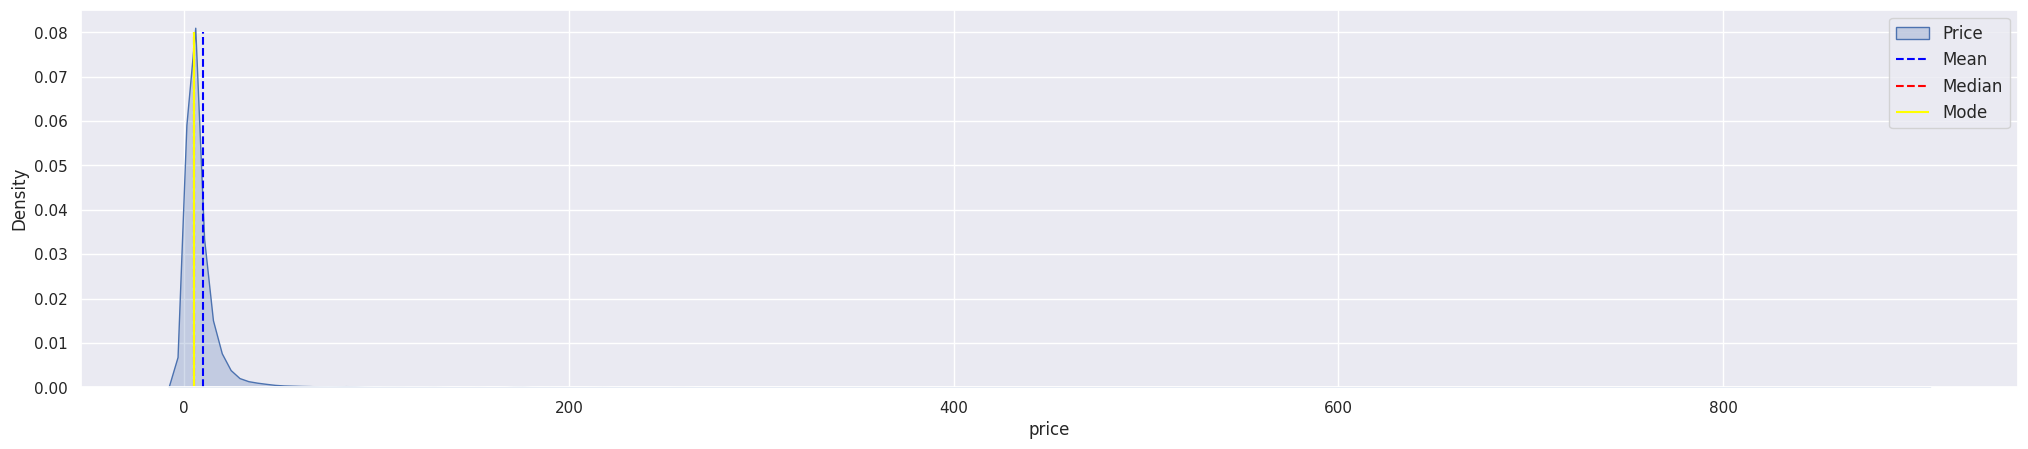

In [ ]:
plt.figure(figsize=(25,5))
sns.kdeplot(price, shade=True)
plt.vlines(x=np.mean(price), ymin=0, ymax=0.08, color='blue', linestyle='--')
plt.vlines(x=scp.mode(price)[0][0], ymin=0, ymax=0.08, color='red', linestyle='--')
plt.vlines(x=np.median(price), ymin=0, ymax=0.08, color='yellow', linestyle='-')
plt.legend(['Price', 'Mean', 'Median', 'Mode'], fontsize=12)
plt.show()

Berdasarkan visualisasi di atas dapat dilihat bahwa median = mode < mean.  Pada kasus ini, nilai median merupakan nilai yang cocok untuk menggambarkan central tendency data. Nilai mean tidak cocok digunakan sebagai central tendency pada data tersebut karena terdapat buku dengan harga yang sangat jauh dari pusat distribusi harga.

## 2. Seberapa kuat hubungan antara jumlah rating dengan skor buku di situs bbe?

**Field yang dimaksud** <br>
Jumlah rating (numRatings): numerik<br>
Skor buku (bbeScore): numerik<br>

**Hubungan** <br>
Karena data tersebut adalah data numerik, gunakan Pearson’s product moment coefficient.

**Interpretasi Rentang nilai Pearson’s product moment coefficient:** <br>

1.  Nilai berkisar dari **-1 (strong negative correlated)** 
2.  ke **0 (tidak ada hubungan/independent)**
3.  sampai ke **+1 (strong positive correlated)**.



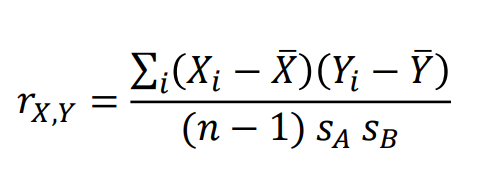

Sumber: Slide Pak Alfan



**Hasil** <br>
Nilai koefisien Pearson yang didapatkan adalah 0.7092. Ini menunjukkan adanya hubungan yang lumayan kuat antara jumlah rating dan skor buku. <br>
Selain itu, didapatkan p-value yang bernilai 0. Dari p-value < 0.05, ada empirical support kalau observasi hal serupa dilakukan pada populasi asli (nilai 0.7092  signifikan)

Korelasi, koef. Pearson:  0.7092247703816008
p-value:  0.0


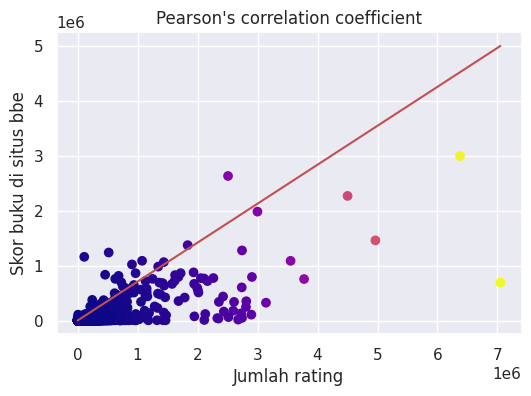

In [ ]:
x = df['numRatings'].dropna()
y = df['bbeScore'].dropna()

# Hitung Pearson's correlation coefficient
corr, p_val = pearsonr(x, y)
print("Korelasi, koef. Pearson: ", corr)
print("p-value: ", p_val)

# Pewarnaan scatterplot
color = x**2 + y**2
plt.scatter(x, y, c=color, cmap='plasma')

# Garis representasi korelasi Pearson
plt.plot([x.min(), x.max()], [corr * x.min() + (1 - corr) * y.mean(), corr * x.max() + (1 - corr) * y.mean()], 'r')

plt.title('Pearson\'s correlation coefficient')
plt.xlabel('Jumlah rating')
plt.ylabel('Skor buku di situs bbe')
#plt.yticks(rotation=45)

plt.show()

##3. Apakah format buku merupakan faktor yang kuat untuk memprediksi harga buku?

**Field yang dimaksud** <br>
Format buku (bookFormat): kategorikal<br>
Harga buku (price): numerik<br>

**Hubungan** <br>
Karena kita mencari hubungan data kategorikal dengan data numerik, gunakan One-Way ANOVA (Analysis of Variance) Test. <br>

Ajukan Null Hypothesis (H0): Sample dari setiap group berasal dari populasi dengan nilai mean yang sama.

Hasilnya reliable jika kriteria berikut terpenuhi:

* Residual variabel respon terdistribusi secara normal,

* Varian populasi sama,

* Respon untuk kelompok tertentu bersifat independen.

Menurut Central Limit Theorems, jika rata-rata kelompok diambil dari populasi dengan nilai rata-rata yang sama, varian antara rata-rata kelompok harus lebih rendah daripada varian sampel.



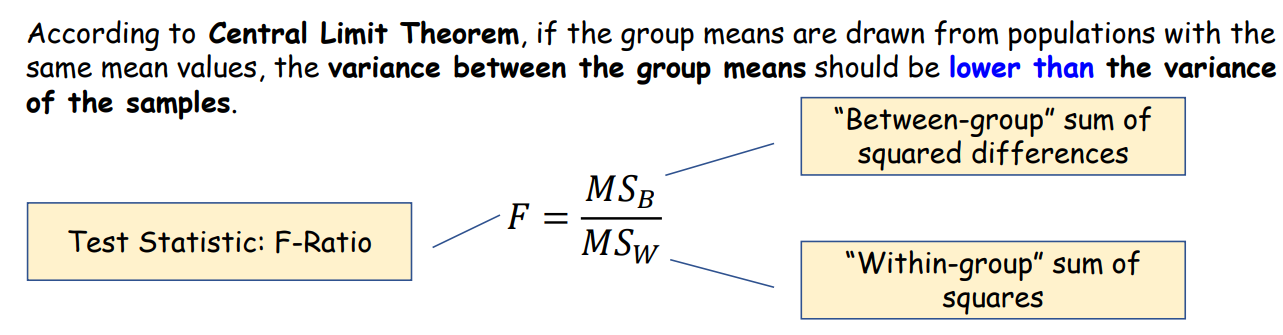
Sumber: Slide Pak Alfan

**Cara menilai Hasil ANOVA:** <br>

* Hasil ANOVA akan valid jika 3 asumsi berikut dipenuhi:
Independence: This refers to the concept that each group is distinct and an individual can only belong to one group. The data collected is not from repeated measurements over time.
* Normality: The assumption of normality is evaluated by analyzing the residuals of the model from an ANOVA or regression perspective. The Shapiro-Wilk test is one way to test for normality.
* Homogeneity of Variance: The last assumption is that all groups have equivalent variances. The Levene's test of homogeneity of variances is a method to verify this assumption.


**Hasil dan Interpretasi:** <br>
Hasil berikut didapatkan dari menjalankan kode yang bisa dilihat di bawah.<br><br>

```
F_onewayResult(statistic=7.646672662738562, pvalue=1.8010826562805014e-30)
LeveneResult(statistic=5.281699729476523, pvalue=3.2627051077628734e-18) 
ShapiroResult(statistic=0.2330951690673828, pvalue=0.0)


                  sum_sq       df         F        PR(>F)
bookFormat  3.441374e+05    135.0  4.381511  3.371860e-38
Residual    2.185650e+07  37567.0       NaN           NaN
```
Kita lakukan One Way ANOVA test menggunakan scipy dan statsmodel. Ini dilakukan untuk mengetahui apakah format buku mempengaruhi harga buku.<br>

Levene's test of homogeneity of variances digunakan untuk memeriksa varians. Jika p-value > 0.05, ga ada perbedaan significant varians antar grup <br>

Dengan metode Shapiro, kita periksa apakah residual dari model terdistribusi normal. ANOVA akan akurat jika residual dari model terdistribusi normal. Grafik dibawah adalah gambaran probability plot dari residual model. <br>

Dari hasil One-Way ANOVA di atas, p-value < 0.05 bisa mengindikasikan bahwa format buku mempengaruhi harga buku. Tapi, beberapa asumsi terkait penggunaan ANOVA ada yang tidak memenuhi (seperti residual model tidak terdistribusi normal dan varians antar group ada indikasi berbeda). Hal ini membuat hasil ANOVA yang diberikan tidak reliable dan bisa jadi tidak valid.

Jadi kesimpulannya, format buku tidak reliable untuk dijadikan faktor untuk memprediksi harga buku.

**Visualisasi:** <br>


1.   Boxplot, cocok untuk menampilkan Measures of Central Tendency umum seperti mean, kuartil, outlier dan lainnya.
2.   probplot, untuk menampilkan probability plot dari residual model, yang bisa dilihat dibawah.




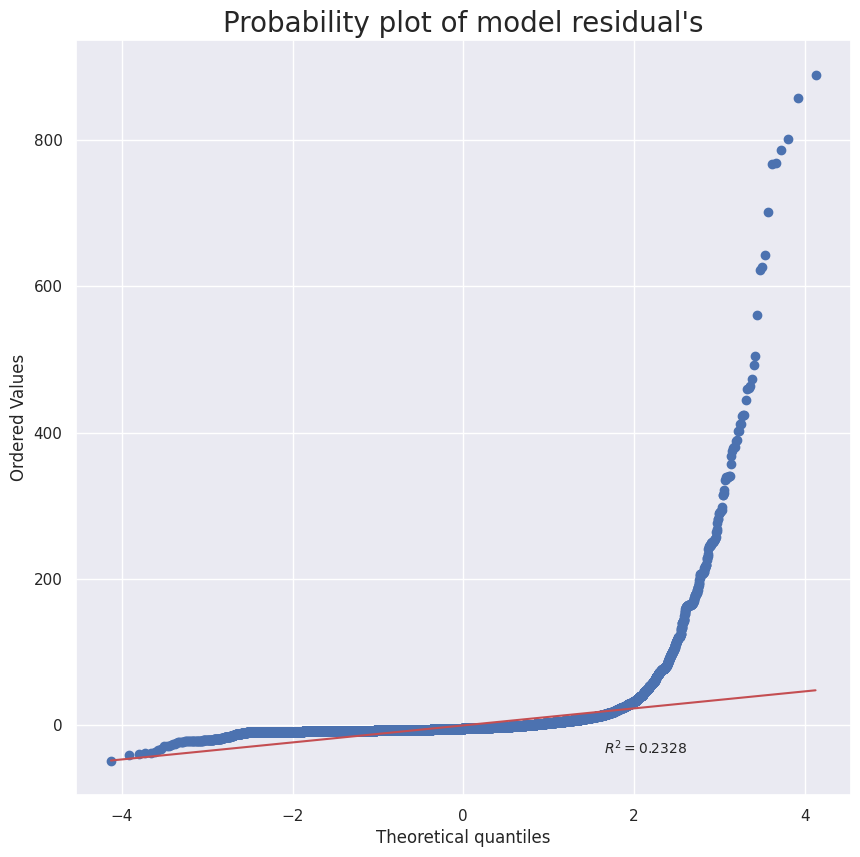

In [5]:
# Menghitung mean harga, stratifikasi dengan format buku
df.groupby(["bookFormat"])["price"].mean().dropna().sort_values(ascending = False)

bookFormat
Capa Mole                            162.485000
Rústica                              119.000000
Digital                               75.950000
Slipcased Hardcover                   75.772000
Bonded Leather                        51.030000
Unbound                               51.025000
Casebound                             47.010000
Audio                                 43.577500
Leather Bound                         42.164286
Tankobon Hardcover                    39.000000
Audio Play                            34.220000
Graphic Novels                        33.035714
Boxed Set                             30.508750
Box Set                               29.706667
Hard cover, Soft cover, e-book        28.920000
Hardcover im Schuber                  26.520000
capa mole                             25.570000
Library Binding                       25.405000
ebook                                 24.601262
Unknown Binding                       22.206552
単行本                          

**Boxplot yang menampilkan persebaran data**


Digunakan boxplot karena boxplot adalah bentuk visualisasi yang baik untuk memperlihatkan persebaran mean, kuartil atas dan bawah, outlier dan lainnya.

Boxplot yang menampilkan persebaran data


<AxesSubplot:title={'center':'price'}, xlabel='[bookFormat]'>

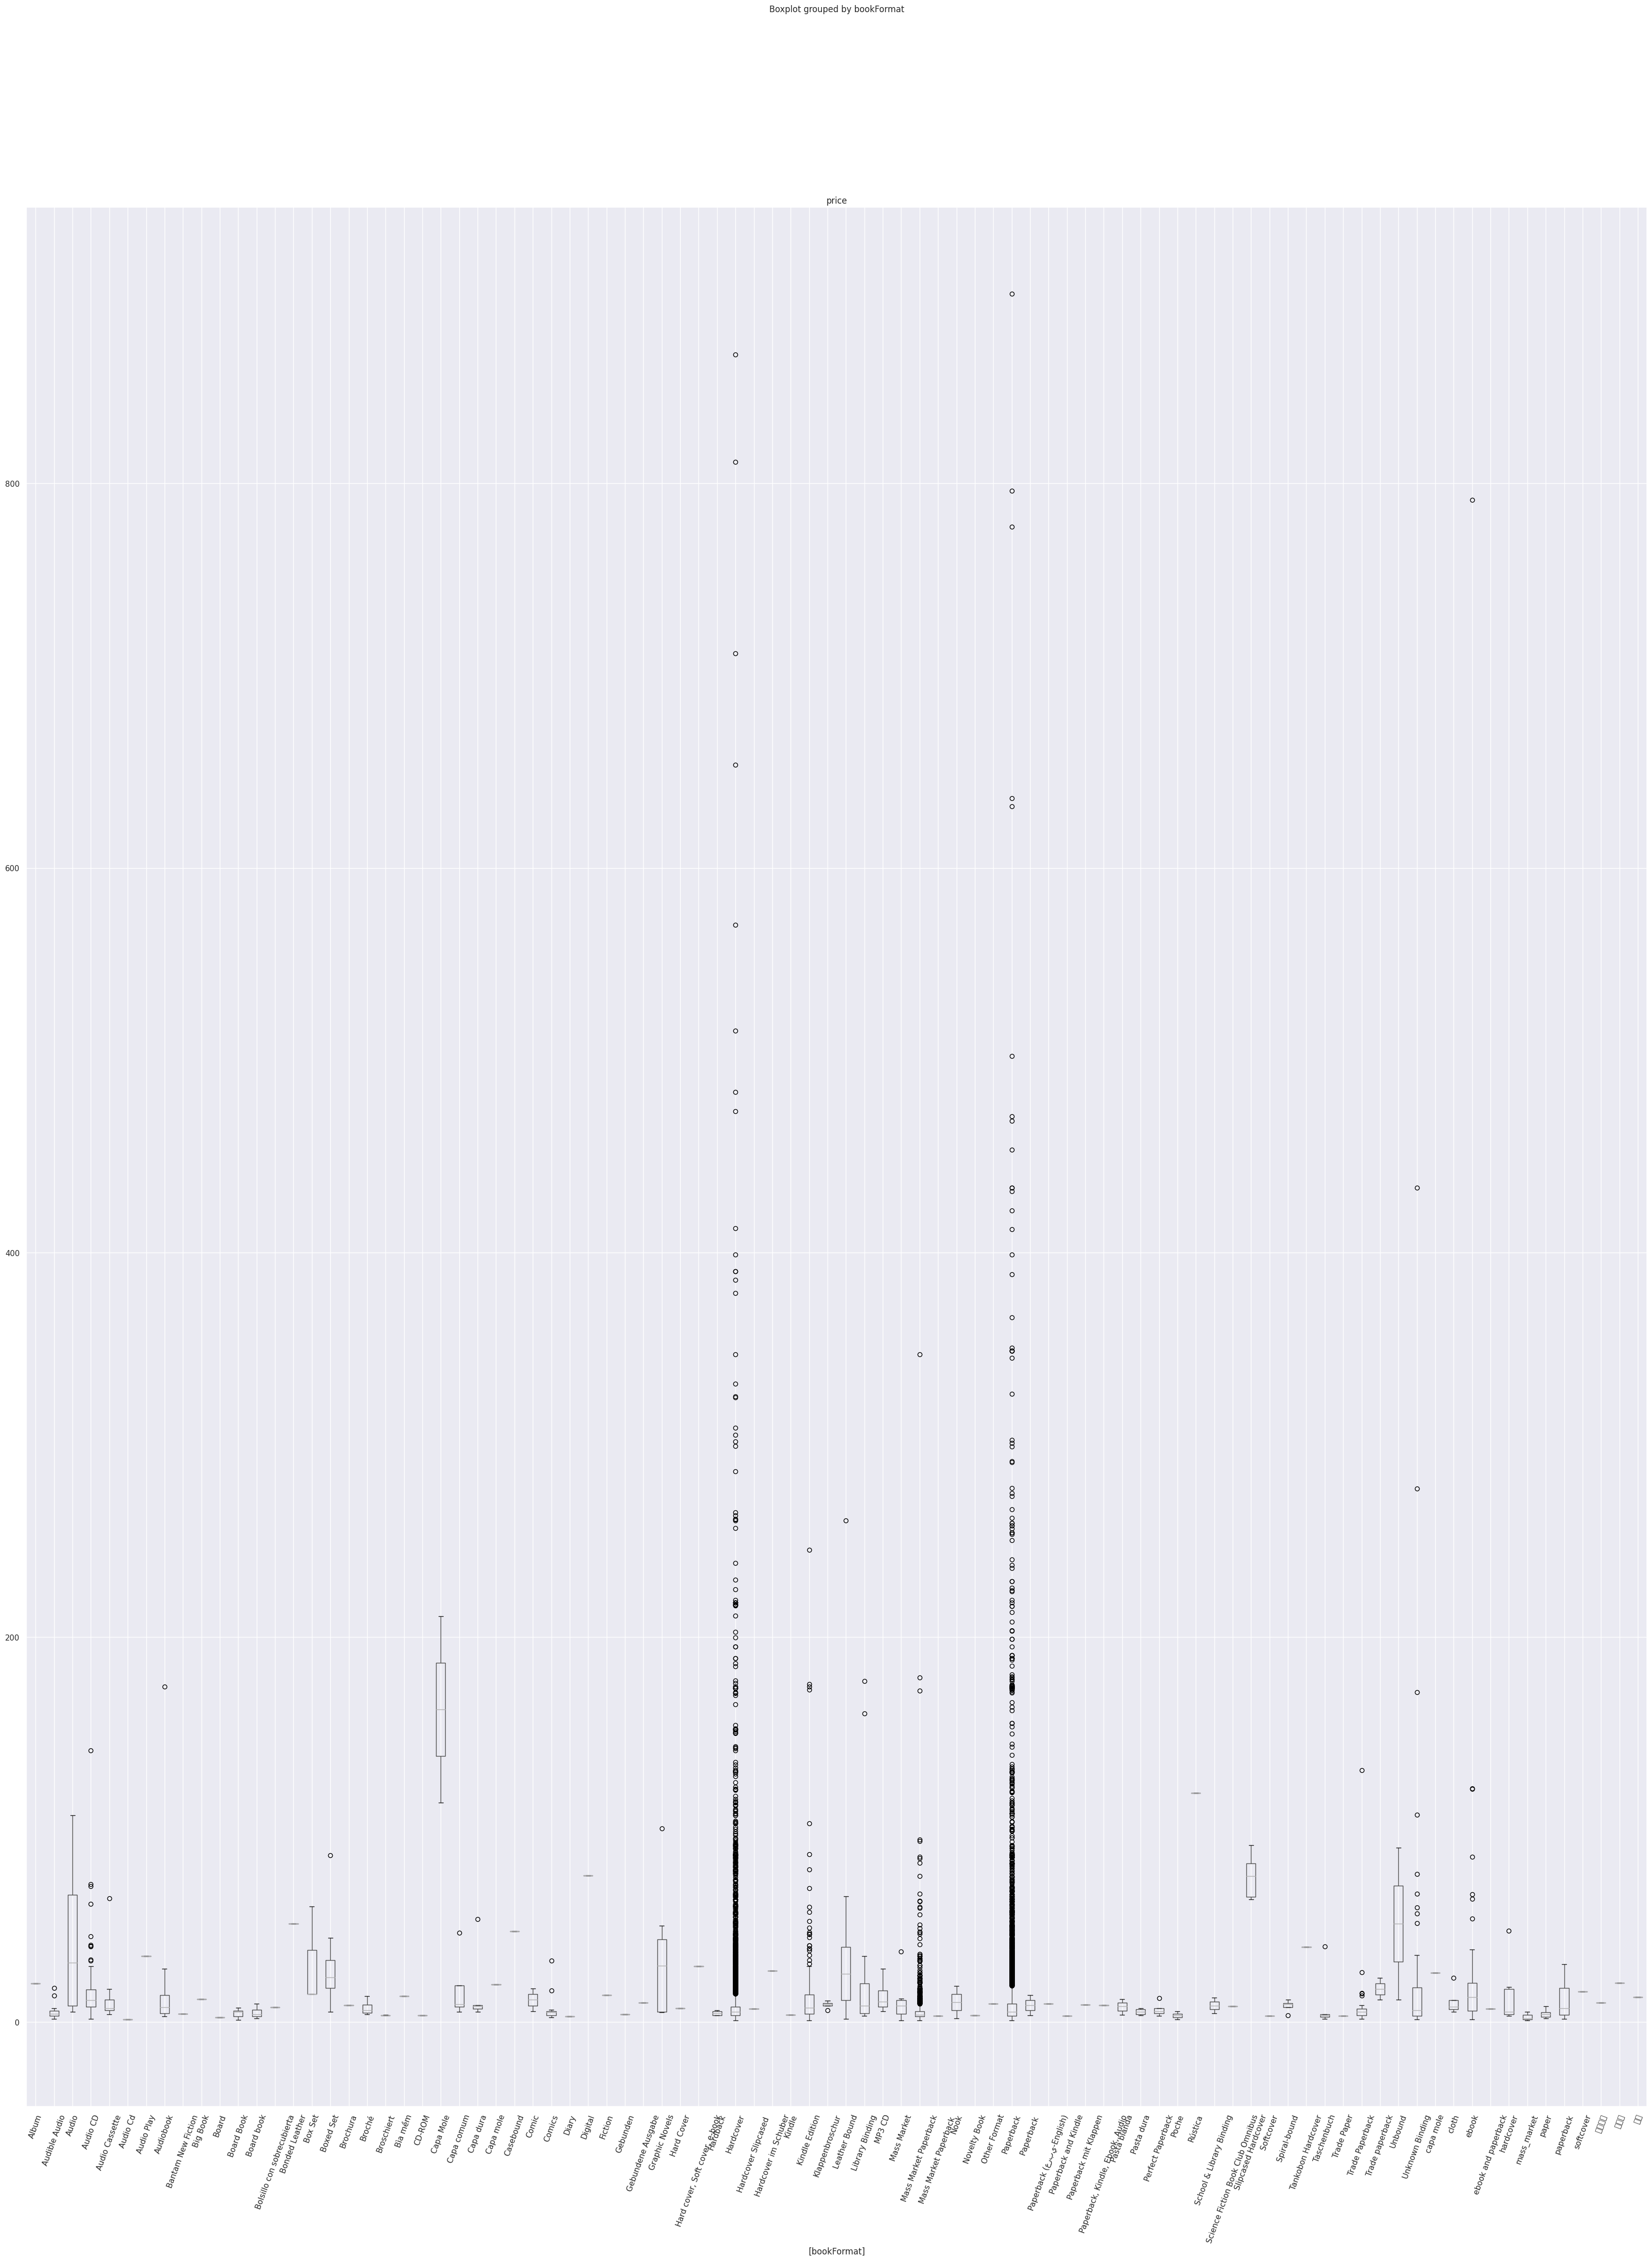

In [6]:
#%%capture
print("Boxplot yang menampilkan persebaran data")

#boxplot dgn bawaan pandas
df[["bookFormat", "price"]].dropna().boxplot(by = "bookFormat", grid = True, rot= 70, figsize=(40, 50))

In [115]:
commnted = '''print(scp.f_oneway( df['price'][df['bookFormat'] == 'Paperback'].dropna(),
             df['price'][df['bookFormat'] == 'Hardcover'].dropna(),
             df['price'][df['bookFormat'] == 'Kindle Edition'].dropna(),
             df['price'][df['bookFormat'] == 'Mass Market Paperback'].dropna(),
             df['price'][df['bookFormat'] == 'ebook'].dropna(),
             df['price'][df['bookFormat'] == 'Audio CD'].dropna(),
             df['price'][df['bookFormat'] == 'Nook'].dropna(),))'''

#Kalau tidak menggunakan kategori yang dibawah 100, sangat lama waktu komputasinya

#commented_a = '''
print(
scp.f_oneway(
df['price'].dropna()[df['bookFormat'] =='Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Hardcover'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Kindle Edition'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Mass Market Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='ebook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio CD'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Nook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audiobook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Unknown Binding'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Trade Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio Cassette'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Library Binding'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audible Audio'].dropna(),
df['price'].dropna()[df['bookFormat'] =='paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Board Book'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Leather Bound'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Comics'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Board book'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Boxed Set'].dropna(),
df['price'].dropna()[df['bookFormat'] =='hardcover'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Mass Market'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Broché'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Perfect Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='paper'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Graphic Novels'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Taschenbuch'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Hardback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Capa dura'].dropna(),

))


F_onewayResult(statistic=7.646672662738562, pvalue=1.8010826562805014e-30)


In [113]:
#print(df['bookFormat'].value_counts().sort_values(ascending=False)) #.index.tolist())

#Generasi semua df book format untuk fungsi diatas

vc = df['bookFormat'].value_counts().sort_values(ascending=False)
vc1 = []
itersss = 0
for a in vc.iteritems():
  if a[1] > 6:
    print("df['price'].dropna()[df['bookFormat'] =='",a[0],"'].dropna(),", sep='')
    itersss = itersss +1
  
print(itersss)

#for index in vc.index.tolist():
  #print(index)

df['price'].dropna()[df['bookFormat'] =='Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Hardcover'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Kindle Edition'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Mass Market Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='ebook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio CD'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Nook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audiobook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Unknown Binding'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Trade Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio Cassette'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Library Binding'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audible Audio'].dropna(),
df['price'].dropna()[df['bookFormat'] =='paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Board Book'].dropna(),
df['price'].dropna()

In [117]:
#print([xbf for xbf in df_anova['bookFormat']])
#for col in df['bookFormat'].unique():
    #print(col)
#print(df_anova['bookFormat'].value_counts())

#scp.f_oneway([df['price'][df['bookFormat'] == xbf].dropna() for xbf in df_anova['bookFormat'].unique()])
#print(a for a in (xbf for xbf in df_anova['bookFormat'].unique()))

#print(a for a in [1,2,3])

#scp.f_oneway([df['price'][df['bookFormat'] == a].dropna() for a in (xbf for xbf in df_anova['bookFormat'].unique())])
#print(df['price'].dropna()[df['bookFormat'] =='単行本'].dropna(),)

commented_aa = '''for a in (xbf for xbf in df['bookFormat'].unique()):
  print("df['price'].dropna()[df['bookFormat'] =='",a,"'].dropna(),", sep='')
  print(df['bookFormat'].value_counts())
  
  for bb in df['price'].dropna()[df['bookFormat'] =='Hardcover'].dropna():
    if np.isnan(bb):
      print("df['price'].dropna()[df['bookFormat'] =='",a,"'].dropna(),", sep='')
      print("NAN")'''
  

In [116]:
df_anova = df[['bookFormat', 'price']]
model = ols('price ~ bookFormat', data=df_anova).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                  sum_sq       df         F        PR(>F)
bookFormat  3.441374e+05    135.0  4.381511  3.371860e-38
Residual    2.185650e+07  37567.0       NaN           NaN


/usr/local/lib/python3.8/dist-packages/statsmodels/base/model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 135, but rank is 87
  warnings.warn('covariance of constraints does not have full '


ShapiroResult(statistic=0.2330951690673828, pvalue=0.0)


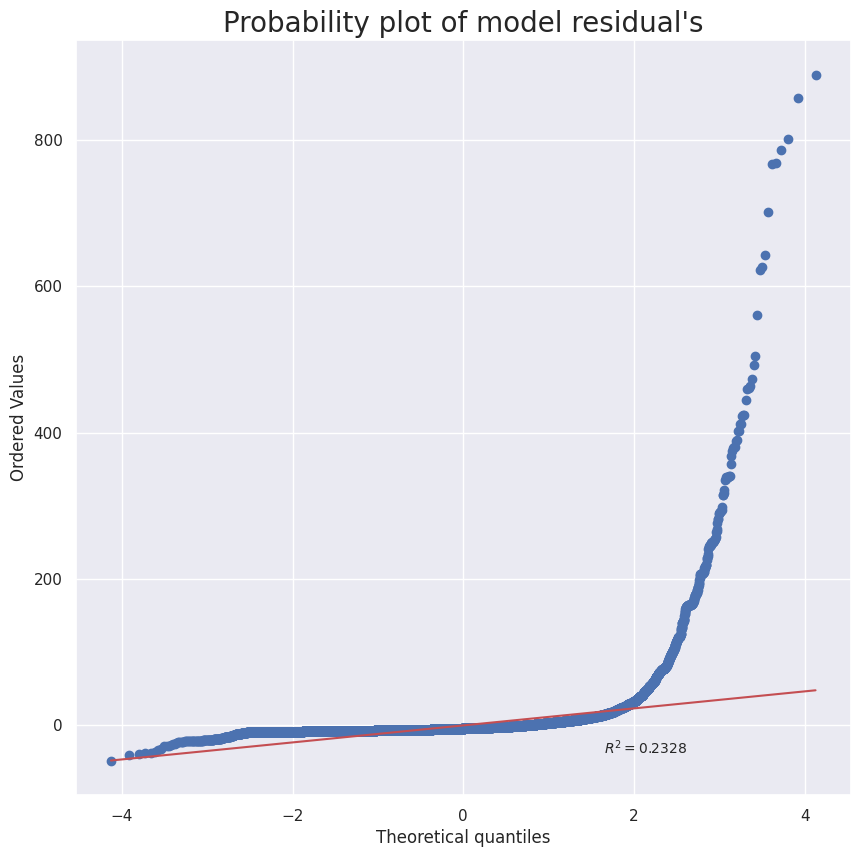

In [120]:
print(stats.shapiro(model.resid))

### plot residual
# ini akan normal jika berada di sekitar garis dibawah
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111)

normality_plot, stat = stats.probplot(model.resid, plot = plt, rvalue = True)
ax.set_title("Probability plot of model residual's", fontsize = 20)

plt.show()

In [121]:
# Levene's test of homogeneity of variances (memeriksa varians)
# jika p-value > 0.05, ga ada perbedaan significant varians antar grup

print(scp.levene( df['price'].dropna()[df['bookFormat'] =='Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Hardcover'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Kindle Edition'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Mass Market Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='ebook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio CD'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Nook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audiobook'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Unknown Binding'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Trade Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio Cassette'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Library Binding'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audible Audio'].dropna(),
df['price'].dropna()[df['bookFormat'] =='paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Board Book'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Leather Bound'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Comics'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Board book'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Audio'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Boxed Set'].dropna(),
df['price'].dropna()[df['bookFormat'] =='hardcover'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Mass Market'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Broché'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Perfect Paperback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='paper'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Graphic Novels'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Taschenbuch'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Hardback'].dropna(),
df['price'].dropna()[df['bookFormat'] =='Capa dura'].dropna(),))


LeveneResult(statistic=5.281699729476523, pvalue=3.2627051077628734e-18)


##4. Bagaimana effect size sekian variabel independen (berhubungan dengan rating, score, jumlah halaman) terhadap harga buku?

**Variabel tersebut adalah bbeVotes, bbeScore, rating, numRatings, likedPercent, pages**

Nilai R-squared (dan versi adjusted) tidak relevan karena disini hanya perlu melihat hubungan variabel tersebut.

Dalam hal ini, yang paling penting adalah coefficient dan p-value. 
* Coefficient menandakan seberapa unit mean dari response variable berubah ketika sebuah independent variable terkait berubah 1 uni. 
* p-value menandakan seberapa significant coefficient dari sebuah independent variable berbeda dari 0 (p-value untuk test H0: coefficient = 0).



```
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     210.6
Date:                Mon, 27 Feb 2023   Prob (F-statistic):          2.32e-265
Time:                        10:18:02   Log-Likelihood:            -1.7381e+05
No. Observations:               37889   AIC:                         3.476e+05
Df Residuals:                   37882   BIC:                         3.477e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -9.9607      2.084     -4.780      0.000     -14.045      -5.877
bbeVotes        -0.0217      0.009     -2.322      0.020      -0.040      -0.003
bbeScore         0.0002   9.66e-05      2.492      0.013    5.14e-05       0.000
rating          19.5995      0.723     27.100      0.000      18.182      21.017
numRatings   -1.197e-05   1.99e-06     -6.005      0.000   -1.59e-05   -8.06e-06
likedPercent    -0.6647      0.040    -16.618      0.000      -0.743      -0.586
page             0.0084      0.001     16.039      0.000       0.007       0.009
==============================================================================
Omnibus:                    73926.510   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        217743921.904
Skew:                          15.513   Prob(JB):                         0.00
Kurtosis:                     373.085   Cond. No.                     1.71e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.71e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
```



**Interpretasi hasil**

Dari regression analysis berikut di bawah, dapat diinterpretasikan:

1. Semua variabel dari bbeVotes, bbeScore, rating, numRatings, likedPercent adalah faktor yang mempengaruhi wage karena nilai p-value < 0.05
2. Dapat interpretasikan kalau mean dari harga naik sebesar 0.0084 ketika jumlah halaman bertambah 1 (lihat coef)
3. Dapat interpretasikan kalau mean dari harga naik sebesar 19.5995 ketika rating bertambah 1 (jangan lupa rentang rating 0-5, tapi menurut saya ini numerik karena ada nilai desimal antara bilangan bulat)
4. Dapat interpretasikan kalau mean dari harga turun sebesar 0.6647 ketika persentase like bertambah 1 (lihat coef)

Seperti yang terlihat dari coef. tabel di atas, tren harga semakin naik jika nilai coef. variabel tertera positif. 

** Visualisasi**

Dalam skenario ini, digunakan "regplot" yang berguna untuk menggambarkan plot untuk linear regression.

Contoh regression plot

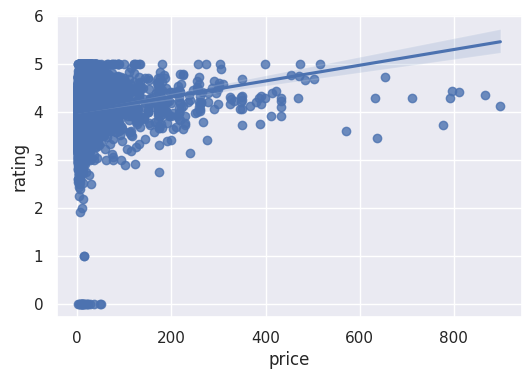

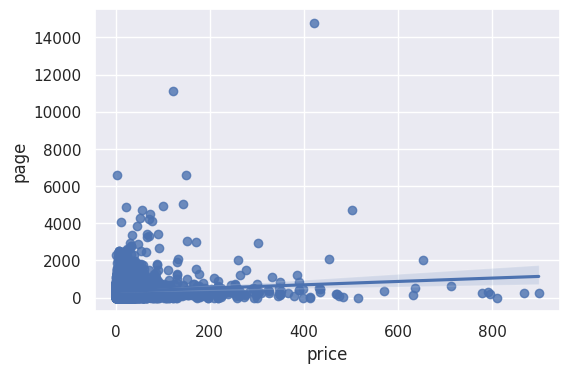








In [10]:
#Preparation
df_es = pd.DataFrame(None)

df_es = df.copy()

df_es['page'] = df_es['pages'].fillna(0)

for i, row in df_es.iterrows():
  try:
      if not row['page'].isnumeric():
        if row['page'] == "1 page":
          #print(row['pages'])
          df_es.at[i, 'page'] = 1
        #print (i)
        #df_es.at[i, 'pages'] = i.replace(' page', '')
  except:
    pass



df_es['page'] = df_es['page'].astype(int)

#for i in df_es['page']:

  #print(int(i))

  #if not isinstance(i, int):
    #print(i)



In [11]:
model = ols(formula = 'price~ bbeVotes + bbeScore + rating + numRatings + likedPercent + page', data = df_es,  ).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     210.6
Date:                Mon, 27 Feb 2023   Prob (F-statistic):          2.32e-265
Time:                        10:18:02   Log-Likelihood:            -1.7381e+05
No. Observations:               37889   AIC:                         3.476e+05
Df Residuals:                   37882   BIC:                         3.477e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -9.9607      2.084     -4.780   

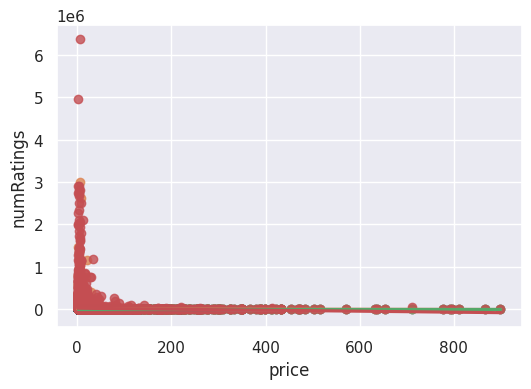

In [47]:
#https://stackoverflow.com/questions/42261976/how-to-plot-statsmodels-linear-regression-ols-cleanly

#model = ols(formula = 'price~ bbeVotes', data = df,  )
#p = model.params

# generate x-values for your regression line (two is sufficient)
#x = np.arange(1, 3)

# scatter-plot data

#fig = sm.graphics.influence_plot(model, criterion="cooks")

#plt = df.plot(x="price", y="bbeVotes", kind="scatter", grid=True)



#ax = df.plot(x="price", y="bbeVotes", kind='scatter')

# plot regression line on the same axes, set x-axis limits
#ax.plot(x, p.bbeVotes + p.price * x)
##ax.set_xlim([1, 2])

#Jawaban dibawah

fig1 = sns.regplot(x="price", y="bbeVotes", data=df, label= "Linear regression model fit ")
fig1.figure.show()



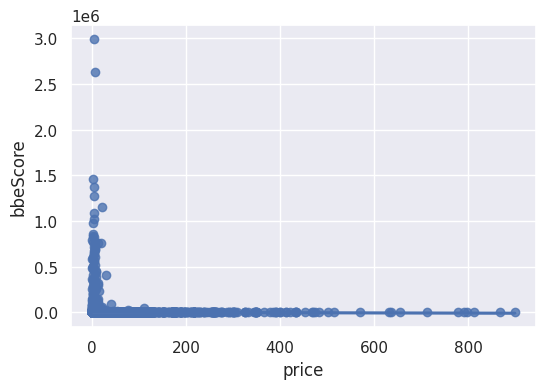

In [48]:
fig2 = sns.regplot(x="price", y="bbeScore", data=df, label= "Linear regression model fit ")
fig2.figure.show()


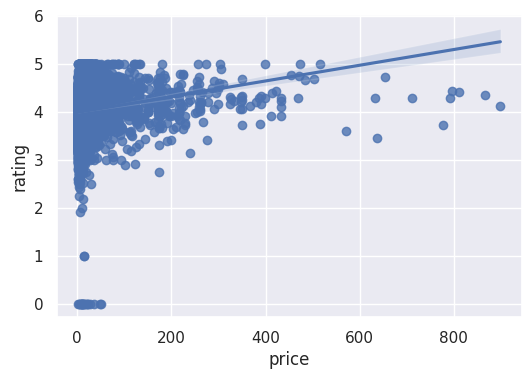

In [49]:
fig3 = sns.regplot(x="price", y="rating", data=df, label= "Linear regression model fit ")
fig3.figure.show()


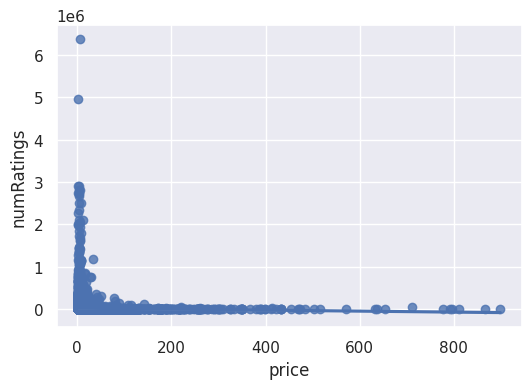

In [50]:
fig4 = sns.regplot(x="price", y="numRatings", data=df, label= "Linear regression model fit ")
fig4.figure.show()

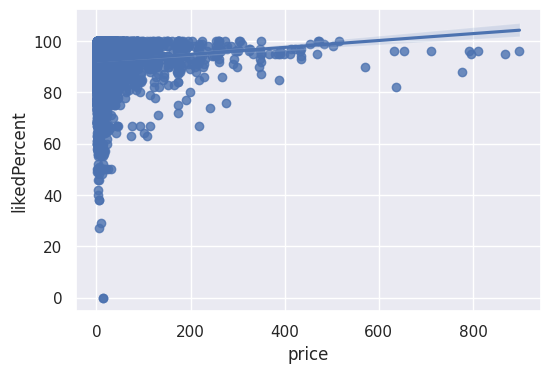

In [52]:
fig5 = sns.regplot(x="price", y="likedPercent", data=df, label= "Linear regression model fit ")
fig5.figure.show()

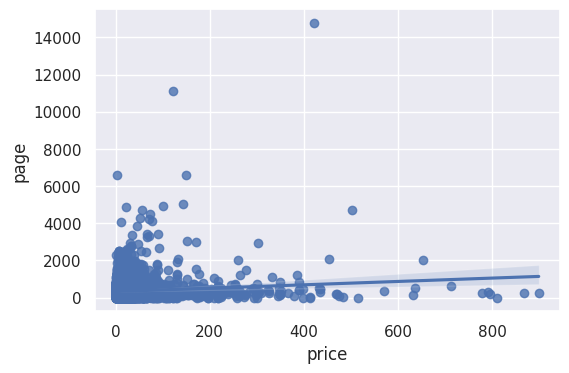

In [12]:
fig6 = sns.regplot(x="price", y="page", data=df_es, label= "Linear regression model fit ")
fig6.figure.show()

## 5. Jelaskan keterkaitan banyaknya jumlah rate bintang satu dengan jumlah halaman buku

**Hubungan** <br>
Karena data tersebut adalah data numerik, gunakan Pearson’s product moment coefficient.

**Data preparation**: <br>
Dari dataframe asli, tidak ada tabel khusus yang berisi jumlah rating per bintang. Tapi ini bisa diakali, kita lakukan data preparation dengan mengubah string representasi array di *ratingsByStars* dilanjutkan dengan mengambil data dengan indeks ke-4.

Dilakukan juga penyesuaian data di pages. Yang awalnya bertipe string harus diubah dulu ke integer. Dilakukan penyesuaian juga karena ada data yang memiliki value berisi alfabet.

**Visualisasi**: <br>
Visualisasi dilakukan dengan:

1. scatterplot dari matplotlib. Ini karena plot cocok untuk merepresentasikan data yang bersifat value numerikal .
2. joint plot dari sns. Bedanya, joint plot menampilkan plot dari dua variabel dengan graph grafik bivariate and univariate.

**Hasil:** <br>
Pearson dan p value:
(0.026108113721744083, 2.216902763812968e-09)
Nilai koefisien Pearson yang didapatkan adalah 0.0.0261. Ini menunjukkan adanya hubungan yang sangat lemah antara jumlah rating bintang 1 dan jumlah halaman. <br>
Selain itu, didapatkan p-value yang bernilai 2.2e-9. Dari p-value < 0.05, ada empirical support kalau observasi hal serupa dilakukan pada populasi asli 


In [60]:
# Preparasi

df_soal5 = pd.DataFrame(None)
df_soal5 = df.copy()


#df_soal5['bintang1_st'] = df['ratingsByStars']   ##.apply(lambda x: x[0])

df_soal5['bintang1'] = df['ratingsByStars']

for i, row in df_soal5.iterrows():
  #print("row", row['title'])
  xx= 5
  for ii in row['ratingsByStars'].split():
    ii = re.sub('[^a-zA-Z0-9 \n\.]', '', ii)
    if ii.isdigit():
      #print("bintang", xx)
      #print(int(ii))
      if xx == 1:
        #print(ii)
        if ii == ('[]') or int(ii) < 1:
          #print("A")
          df_soal5.at[i,'bintang1'] = 0
        df_soal5.at[i,'bintang1'] = int(ii)
        
      xx = xx-1


#print(df_soal5.head())




In [61]:
for i, row in df_soal5.iterrows():
  #if not row['bintang1'].isdigit():
  #Handle kalau array rating by stars emg kosong
  #if i == 4968 or i == 5003 or i ==  5715 or i ==  8316 or i == 8320 or i == 11130 or i == 11248 or i == 11312:
    #print(row)
  if row['bintang1'] == "[]":
    df_soal5.at[i,'bintang1'] = 0

In [62]:
for i, row in df_soal5.iterrows():
  try:
      if not row['pages'].isnumeric():
        if row['pages'] == "1 page":
          #print(row['pages'])
          df_soal5.at[i, 'pages'] = 1
        #print (i)
        #df_es.at[i, 'pages'] = i.replace(' page', '')
  except:
    pass
df_soal5['pages'] = df_soal5['pages'].fillna(0)
df_soal5['pages'] = df_soal5['pages'].astype(int)

In [63]:
print("Pearson dan p value:")
print(pearsonr(df_soal5["bintang1"], df_soal5["pages"]))

Pearson dan p value:
(0.026108113721744083, 2.216902763812968e-09)


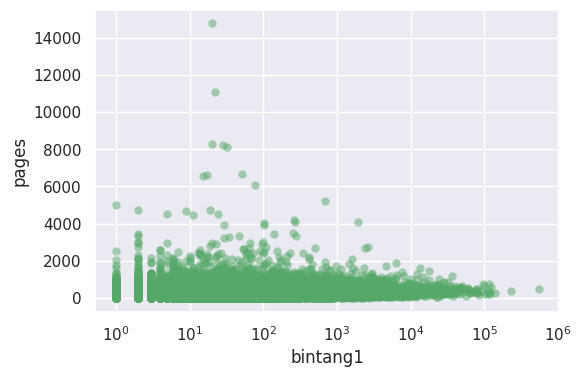

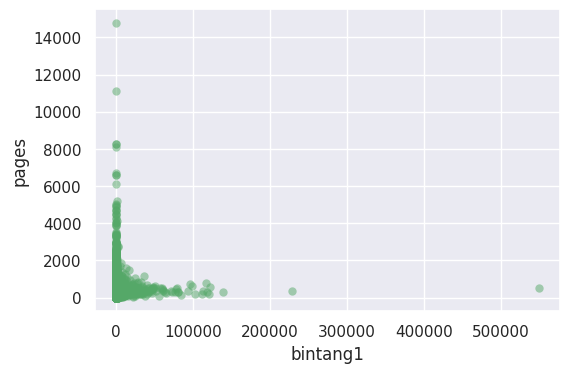

In [64]:
df_soal5['bintang1'] = df_soal5['bintang1'].fillna(0)

#plt.xscale("log")

#df_soal5.plot.xscale("log")

plot5 = df_soal5.plot
plt.xscale("log")

plt.scatter(x = df_soal5['bintang1'], y = df_soal5['pages'], c = 'g', alpha = 0.5, linewidth = 0)
plt.xlabel("bintang1")
plt.ylabel("pages")
plt.show()

plt.xscale("linear")

plt.scatter(x = df_soal5['bintang1'], y = df_soal5['pages'], c = 'g', alpha = 0.5, linewidth = 0)
plt.xlabel("bintang1")
plt.ylabel("pages")
plt.show()
#soal5_graph = sns.jointplot(data=df_soal5, x="bintang1", 
#                            y="pages",
#                  kind="reg", color="m", height=7,
#                  joint_kws={'line_kws':{'color':'black'}})

In [87]:
#plt.hist(x = df_soal5.bintang1, y = df_soal5.pages, color = 'blue', alpha = 0.5, linewidth = 0, )
#plt.xlabel("bintang1")
#plt.ylabel("pages")

#hist = df_soal5.hist(y = 'bintang1')

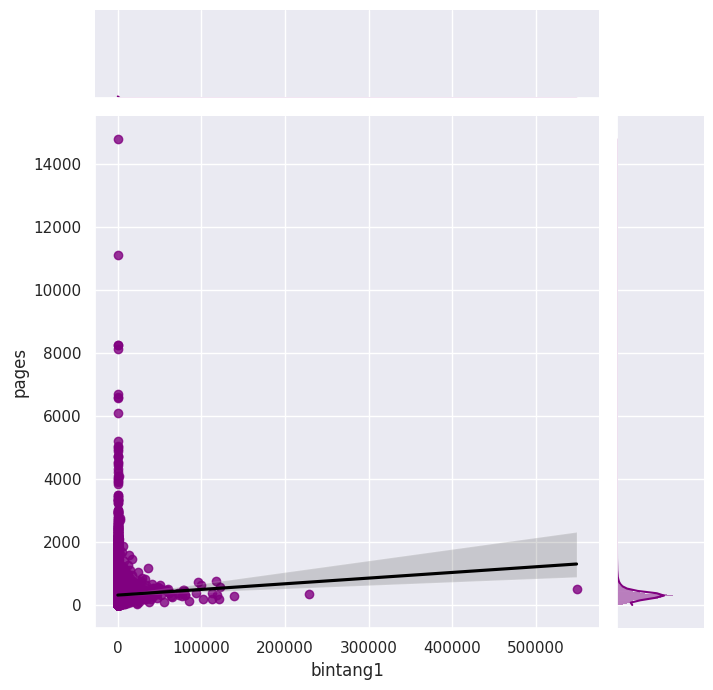

In [89]:
g = sns.jointplot(data=df_soal5, x="bintang1", y="pages",
                  kind="reg", color="purple", height=7,
                  joint_kws={'line_kws':{'color':'black'}})

## 6. Apakah hubungan antar beberapa variabel numerikal di dataframe ini? Gunakan metode Pearson. Berikan juga heat map-nya.

Variabel tersebut adalah: bbeScore bbeVotes	price rating pages

**Visualisasi**<br>
Visualisasi di skenario ini menggunakan heat map. Heat map memetakan data dalam kotak-kotak matriks yang di-encoding dengan warna. Dalam skenario ini, heat map memvisualisasikan korelasi pearson.

**Analisis** <br>
Kita lihat nilai korelasi bbeScore dan bbeVotes dibawah. Dari sifat korelasi Pearson dimana semakin mendekati 1 semakin strong positive correlated, bisa juga dibilang bahwa hubungan kedua variabel tersebut sangat mirip dan bisa dibilang redundan. <br>

Kita lihat lagi nilai-nilai positif yang mendekati 0, yang di grafik heat map berwarna cenderung merah. Ini menandakan adanya kolerasi positif, meskipun sangat lemah. Korelasi positif bisa dibilang jika variabel pertama bergerak ke satu arah, variabel yang memiliki kolerasi positif dengannya bergerak ke arah yang sama. <br>

Kita lihat lagi nilai-nilai negatif yang mendekati 0, yang di grafik heat map berwarna cenderung biru. Ini menandakan adanya kolerasi negatif, meskipun sangat lemah. Korelasi negatif bisa dibilang jika variabel pertama bergerak ke satu arah, variabel yang memiliki kolerasi negatif dengannya bergerak ke arah yang berlawanan. <br>

In [57]:
matriks_kolerasi = df_soal5[['bbeScore', 'bbeVotes', 'price', 'rating', 'pages', 'bintang1']].corr(method = "pearson")
print(matriks_kolerasi)

          bbeScore  bbeVotes     price    rating     pages  bintang1
bbeScore  1.000000  0.999303 -0.008474  0.015363  0.026890  0.528336
bbeVotes  0.999303  1.000000 -0.009302  0.015560  0.028198  0.533514
price    -0.008474 -0.009302  1.000000  0.124743  0.093433 -0.018761
rating    0.015363  0.015560  0.124743  1.000000  0.079585 -0.025127
pages     0.026890  0.028198  0.093433  0.079585  1.000000  0.026108
bintang1  0.528336  0.533514 -0.018761 -0.025127  0.026108  1.000000


Text(0.5, 1.0, 'Korelasi Pearson variabel numerikal')

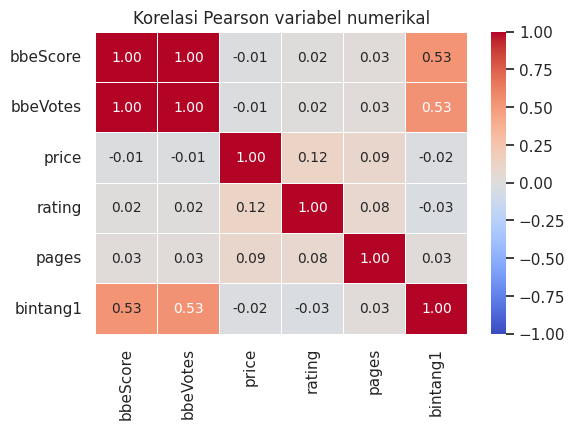

In [58]:
sns.heatmap(matriks_kolerasi, vmin=-1., vmax=1., annot=True, fmt='.2f', cmap="coolwarm", cbar=True, linewidths=0.6)
plt.title("Korelasi Pearson variabel numerikal")